<a href="https://colab.research.google.com/github/SamikshKodgire/AAI-590_CapstoneProject/blob/main/AAI590_CApstoneProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intelligent Cross-Repository Bug Priority Prediction Using Machine Learning and Transformer Models

### AAI-590 Capstone Project

**Team Members:**
- Samiksha Kodgire
- Manoj Nair



Background

Software maintenance represents one of the most resource-intensive phases of the Software Development Life Cycle (SDLC). Large-scale software projects receive thousands of bug reports throughout their lifetime, requiring engineering teams to continuously review, classify, prioritize, and resolve reported issues. As projects grow in size and complexity, manually triaging these reports becomes increasingly challenging due to the volume of incoming issues, variations in reporting quality, and differences in project-specific workflows.

Bug prioritization plays a central role in software maintenance because it directly influences resource allocation, release planning, and overall software quality. Incorrect or inconsistent prioritization may delay the resolution of critical defects while allocating unnecessary effort to lower-impact issues. Consequently, there is growing interest in developing intelligent decision-support systems capable of assisting developers during the bug triage process.

Recent advances in Natural Language Processing (NLP), machine learning, and transformer-based language models have demonstrated significant potential for understanding unstructured software engineering text. By learning semantic patterns from historical bug reports, these models can assist development teams in automatically identifying issue priorities, reducing manual effort, and improving the consistency of software maintenance activities.

Problem Statement

This project investigates the development of an intelligent bug triage system capable of automatically predicting the priority of software bug reports using their textual content.

To achieve this objective, bug reports collected from multiple large-scale open-source software repositories are consolidated into a unified corpus. The resulting dataset contains both structured issue metadata and unstructured textual descriptions originating from diverse software projects. Such diversity introduces practical challenges, including heterogeneous priority schemes, repository-specific workflows, incomplete metadata, and varying reporting conventions.

The study aims to address these challenges through systematic data preprocessing, feature engineering, and supervised machine learning while evaluating the effectiveness of both traditional machine learning algorithms and transformer-based deep learning models for automated bug priority prediction.

Research Objectives

This project is guided by the following research questions:

RQ1. Can textual information contained within software bug reports accurately predict issue priority across multiple open-source software repositories?

RQ2. How do traditional machine learning approaches compare with transformer-based deep learning models for cross-repository bug priority prediction?

RQ3. How do repository-specific characteristics, heterogeneous priority labels, and incomplete metadata influence predictive performance?

To address these questions, the project pursues the following objectives:

Construct a unified cross-repository bug report corpus from multiple open-source software projects.
Perform comprehensive data understanding, quality assessment, and exploratory data analysis.
Design a robust preprocessing pipeline capable of handling noisy software engineering text.
Generate textual feature representations using both TF-IDF vectorization and transformer tokenization techniques.
Develop and compare multiple traditional machine learning models for bug priority prediction.
Fine-tune a transformer-based deep learning model using the unified bug corpus.
Evaluate model performance using standard classification metrics and perform detailed error analysis.
Assess the practical applicability of AI-assisted bug triage systems within modern software engineering workflows.
Dataset Overview

The project utilizes the Git Bugs Dataset, comprising approximately 192,000 historical bug reports collected from nine major open-source software repositories, including Apache, Mozilla, Firefox, Visual Studio Code, Thunderbird, Spark, Hadoop, Cassandra, HBase, and SeaMonkey.

Each bug report contains structured metadata (such as issue status, timestamps, repository information, and resolution details) together with unstructured textual information including the issue summary and detailed description. The textual attributes serve as the primary input for the predictive models, while the reported bug priority is investigated as the target variable.

To improve model robustness and evaluate cross-project generalization, all repository-specific datasets are integrated into a unified corpus while preserving repository provenance as an additional metadata attribute for downstream analysis.

## Machine Learning Pipeline

The overall workflow adopted in this study is illustrated below:

```
Raw Repository Data
        │
        ▼
Dataset Integration
        │
        ▼
Data Understanding & Quality Assessment
        │
        ▼
Data Quality Assessment
        │
        ▼
Target Variable Harmonization
        │
        ▼
Data Cleaning & Text Preprocessing
        │
        ▼
Exploratory Data Analysis
        │
        ▼
Feature Engineering
        │
 ┌──────────────┴──────────────┐
 ▼                             ▼
TF-IDF Vectorization      BERT Tokenization
 │                             │
 └──────────────┬──────────────┘
                ▼
Model Development
 │
 ├── Logistic Regression
 ├── Random Forest
 ├── XGBoost
 └── BERT
                │
                ▼
Model Evaluation
                │
                ▼
Comparative Analysis
                │
                ▼
Error Analysis
                │
                ▼
Conclusions & Future Work
```

# 1. Environment Setup

## Objectives

This section prepares the computational environment required for the project by installing the necessary libraries, importing dependencies, and creating a structured workspace for the project.

A consistent project structure improves reproducibility, facilitates experiment management, and enables intermediate artifacts to be saved throughout the machine learning pipeline.

---

## Methodology

The project is developed using Google Colab, where all computations are performed within the runtime environment. The raw dataset will be uploaded as a compressed ZIP archive and processed locally to maximize input/output performance.

Throughout the notebook, intermediate outputs such as cleaned datasets, trained models, visualizations, and checkpoints will be stored within the runtime workspace. This modular approach allows later sections of the notebook to be executed independently without rerunning previous stages.

---

## Expected Output

Upon completion of this section:

- All required libraries are installed.
- Project dependencies are imported.
- Runtime directories are created.
- The notebook is ready for data acquisition.

In [5]:
# ============================================================
# Install Required Packages
# ============================================================

!pip install -q transformers datasets accelerate
!pip install -q sentencepiece
!pip install -q xgboost
!pip install -q wordcloud
!pip install -q textstat
!pip install -q contractions
!pip install -q evaluate
!pip install -q nltk

In [6]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import os
import re
import gc
import shutil
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Plot configuration
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [7]:
# ==========================================================
# Create Project Directory Structure
# ==========================================================

PROJECT_ROOT = Path("/content/GitBug_AI_Project")

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

MODEL_DIR = PROJECT_ROOT / "models"

RESULT_DIR = PROJECT_ROOT / "results"

FIGURE_DIR = PROJECT_ROOT / "figures"

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

for directory in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    MODEL_DIR,
    RESULT_DIR,
    FIGURE_DIR,
    CHECKPOINT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project workspace created at:\n{PROJECT_ROOT}")

Project workspace created at:
/content/GitBug_AI_Project


In [8]:
# ==========================================================
# Verify Project Structure
# ==========================================================

print("Project Directory Structure:\n")

for path in PROJECT_ROOT.rglob("*"):
    if path.is_dir():
        print(path)

Project Directory Structure:

/content/GitBug_AI_Project/data
/content/GitBug_AI_Project/checkpoints
/content/GitBug_AI_Project/results
/content/GitBug_AI_Project/models
/content/GitBug_AI_Project/figures
/content/GitBug_AI_Project/data/raw
/content/GitBug_AI_Project/data/processed


### Design Decision

Rather than mounting external cloud storage, the project uses Google Colab's local runtime as the primary workspace. Processing data locally provides faster file access and simplifies project execution.

The notebook is organised into modular stages, with intermediate datasets, trained models, figures, and other artifacts saved as checkpoints within the project workspace. This enables individual sections of the notebook to be rerun independently, reducing redundant computation and supporting efficient experimentation.

## Section Summary

The computational environment has been successfully configured, and a standardized project workspace has been established. The notebook is now prepared to ingest the raw dataset and begin the data acquisition process.

The next section focuses on uploading the compressed Git Bugs dataset, extracting its contents, inspecting the available files, and loading the raw data into a Pandas DataFrame for further analysis.

# 2. Data Acquisition

## Objectives

This section focuses on acquiring and validating the raw dataset required for the project.

The dataset is provided as a compressed ZIP archive containing software bug reports collected from Git repositories. Before any analysis can be performed, the archive must be uploaded, extracted, and its contents verified.

The objectives of this section are to:

- Upload the raw dataset to the Colab runtime.
- Extract the compressed archive.
- Inspect the extracted directory structure.
- Identify all available CSV files.
- Load the appropriate dataset into a Pandas DataFrame.
- Preserve an immutable copy of the raw dataset for future reference.

---

## Methodology

Data acquisition is the first stage of the machine learning pipeline. Rather than assuming a fixed file structure, the notebook dynamically discovers the extracted files, making the workflow robust to future dataset updates.

Before loading the dataset into memory, basic validation checks are performed to ensure the archive has been extracted successfully and that the expected data files are available.

Maintaining an unchanged copy of the raw dataset allows all subsequent preprocessing steps to remain reproducible and traceable.

---

## Expected Output

At the completion of this section:

- The dataset archive has been successfully extracted.
- The extracted files have been verified.
- The primary CSV file has been loaded into a Pandas DataFrame.
- Basic dataset metadata has been displayed.
- A raw copy of the dataset has been stored within the project workspace.

In [11]:
# ==========================================================
# Upload Dataset
# ==========================================================

from google.colab import files

print("Please upload the Git Bugs dataset (.zip)")

uploaded = files.upload()

Please upload the Git Bugs dataset (.zip)


Saving archive.zip to archive.zip


In [12]:
# ==========================================================
# Locate Uploaded ZIP File
# ==========================================================

zip_files = list(Path("/content").glob("*.zip"))

if not zip_files:
    raise FileNotFoundError("No ZIP file found in the runtime.")

zip_path = zip_files[0]

print(f"Dataset found:\n{zip_path}")

Dataset found:
/content/archive.zip


In [13]:
# ==========================================================
# Extract Dataset
# ==========================================================

EXTRACT_DIR = RAW_DATA_DIR / "gitbugs"

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [14]:
# ==========================================================
# Display Extracted Directory Structure
# ==========================================================

print("Extracted Files:\n")

for path in sorted(EXTRACT_DIR.rglob("*")):
    print(path.relative_to(EXTRACT_DIR))

Extracted Files:

gitbugs
gitbugs/cassandra
gitbugs/cassandra/cassandra_bugs-combined.csv
gitbugs/cassandra/cassandra_bugs.csv
gitbugs/firefox
gitbugs/firefox/Firefox_bugs-combined.csv
gitbugs/firefox/Firefox_bugs.csv
gitbugs/hadoop
gitbugs/hadoop/hadoop_bugs-combined.csv
gitbugs/hadoop/hadoop_bugs.csv
gitbugs/hbase
gitbugs/hbase/hbase_bugs-combined.csv
gitbugs/hbase/hbase_bugs.csv
gitbugs/mozillacore
gitbugs/mozillacore/Core_bugs-combined.csv
gitbugs/mozillacore/Core_bugs.csv
gitbugs/ms_vscode_bugs
gitbugs/ms_vscode_bugs/vscode_bugs-combined.csv
gitbugs/ms_vscode_bugs/vscode_bugs.csv
gitbugs/seamonkey
gitbugs/seamonkey/SeaMonkey_bugs-combined.csv
gitbugs/seamonkey/SeaMonkey_bugs.csv
gitbugs/spark
gitbugs/spark/spark_bugs-combined.csv
gitbugs/spark/spark_bugs.csv
gitbugs/thunderbird
gitbugs/thunderbird/Thunderbird_bugs-combined.csv
gitbugs/thunderbird/Thunderbird_bugs.csv


In [15]:
# ==========================================================
# Create Dataset Inventory
# ==========================================================

inventory = []

csv_files = sorted(EXTRACT_DIR.rglob("*.csv"))

for file in csv_files:
    inventory.append({
        "Repository": file.parent.name,
        "Filename": file.name,
        "Type": "Combined" if "combined" in file.name.lower() else "Raw",
        "Size (MB)": round(file.stat().st_size / (1024**2), 2),
        "Path": str(file.relative_to(EXTRACT_DIR))
    })

inventory_df = pd.DataFrame(inventory)

display(inventory_df)

,Repository,Filename,Type,Size (MB),Path
0,cassandra,cassandra_bugs-combined.csv,Combined,0.01,gitbugs/cassandra/cassandra_bugs-combined.csv
1,cassandra,cassandra_bugs.csv,Raw,6.81,gitbugs/cassandra/cassandra_bugs.csv
2,firefox,Firefox_bugs-combined.csv,Combined,0.12,gitbugs/firefox/Firefox_bugs-combined.csv
3,firefox,Firefox_bugs.csv,Raw,56.89,gitbugs/firefox/Firefox_bugs.csv
4,hadoop,hadoop_bugs-combined.csv,Combined,0.00,gitbugs/hadoop/hadoop_bugs-combined.csv
5,hadoop,hadoop_bugs.csv,Raw,2.56,gitbugs/hadoop/hadoop_bugs.csv
6,hbase,hbase_bugs-combined.csv,Combined,0.00,gitbugs/hbase/hbase_bugs-combined.csv
7,hbase,hbase_bugs.csv,Raw,5.35,gitbugs/hbase/hbase_bugs.csv
8,mozillacore,Core_bugs-combined.csv,Combined,0.34,gitbugs/mozillacore/Core_bugs-combined.csv
9,mozillacore,Core_bugs.csv,Raw,346.09,gitbugs/mozillacore/Core_bugs.csv


In [16]:
# ==========================================================
# Inspect Sample Raw and Combined Datasets
# ==========================================================

raw_file = next(EXTRACT_DIR.rglob("*_bugs.csv"))
combined_file = next(EXTRACT_DIR.rglob("*combined.csv"))

print("="*80)
print("RAW DATASET")
print("="*80)

raw_sample = pd.read_csv(raw_file)

print(f"Shape : {raw_sample.shape}")

display(raw_sample.head())

print("\nColumns:")
display(pd.DataFrame(raw_sample.columns, columns=["Column Name"]))


print("\n" + "="*80)
print("COMBINED DATASET")
print("="*80)

combined_sample = pd.read_csv(combined_file)

print(f"Shape : {combined_sample.shape}")

display(combined_sample.head())

print("\nColumns:")
display(pd.DataFrame(combined_sample.columns, columns=["Column Name"]))

RAW DATASET
Shape : (2503, 9)


,Summary,Issue id,Status,Priority,Resolution,Created,Resolved,Affects Version/s,Description
0,JAR in conflict with timestamp check causes AM...,13404344,Resolved,Blocker,Duplicate,30/Sep/21 17:20,20/Jul/22 20:51,2.9.2,After an init action pulls down a new JAR and ...
1,Fix Hadoop build on Debian 10,13400058,Resolved,Blocker,Fixed,08/Sep/21 17:46,18/Sep/21 18:52,3.4.0,We're using *Debian testing* as one of the pac...
2,Filter deps with release labels,13401369,Resolved,Blocker,Fixed,15/Sep/21 11:42,16/Sep/21 16:19,3.4.0,We need to add the ability to filter the depen...
3,ABFS AbfsDelegationTokenManager to generate ca...,13401382,Open,Critical,NaN,15/Sep/21 12:43,NaN,3.3.1,"Currently in {{AbfsDelegationTokenManager}}, a..."
4,BuiltInGzipCompressor header and trailer shoul...,13397934,Resolved,Critical,Fixed,28/Aug/21 06:00,09/Sep/21 04:25,3.4.0,"In the newly added BuiltInGzipCompressor, we s..."



Columns:


,Column Name
0,Summary
1,Issue id
2,Status
3,Priority
4,Resolution
5,Created
6,Resolved
7,Affects Version/s
8,Description



COMBINED DATASET
Shape : (126, 2)


,Issue id,Duplicate id
0,13478269,13478452
1,13420488,13420194
2,13314197,13313687
3,13289655,13286152
4,13288139,13287181



Columns:


,Column Name
0,Issue id
1,Duplicate id


In [17]:
# ==========================================================
# Load and Merge All Bug Datasets
# ==========================================================

raw_files = sorted(EXTRACT_DIR.rglob("*_bugs.csv"))

print(f"Repositories Found: {len(raw_files)}")

dataframes = []

for file in raw_files:

    temp = pd.read_csv(file)

    # Preserve repository source
    temp["Repository"] = file.parent.name

    dataframes.append(temp)

df = pd.concat(dataframes, ignore_index=True)

print("\nMaster dataset created successfully.")

print(f"Total Bug Reports : {len(df):,}")
print(f"Repositories      : {df['Repository'].nunique()}")
print(f"Columns           : {len(df.columns)}")

Repositories Found: 9

Master dataset created successfully.
Total Bug Reports : 192,387
Repositories      : 9
Columns           : 10


In [18]:
# ==========================================================
# Dataset Overview
# ==========================================================

summary = pd.DataFrame({

    "Attribute": [
        "Rows",
        "Columns",
        "Repositories",
        "Missing Values",
        "Duplicate Rows",
        "Memory Usage (MB)"
    ],

    "Value": [

        df.shape[0],

        df.shape[1],

        df["Repository"].nunique(),

        int(df.isna().sum().sum()),

        int(df.duplicated().sum()),

        round(df.memory_usage(deep=True).sum()/1024**2,2)

    ]

})

display(summary)

,Attribute,Value
0,Rows,192387.00
1,Columns,10.00
2,Repositories,9.00
3,Missing Values,290361.00
4,Duplicate Rows,1.00
5,Memory Usage (MB),614.68


In [26]:
# ==========================================================
# Dataset Preview
# ==========================================================

display(df.sample(10, random_state=42))

,Summary,Issue id,Status,Priority,Resolution,Created,Resolved,Description,Repository,Affects Version/s
12393,A tab-specific infobar is displayed above the ...,1709420,NEW,P3,NaN,2021-05-04 17:59:27+00:00,2021-06-01 15:48:53+00:00,"**Note**\n* When the user triggers the ""Captiv...",firefox,NaN
87047,Intermittent /custom-elements/form-associated...,1790358,REOPENED,P5,NaN,2022-09-12 11:42:22+00:00,2025-02-24 06:31:15+00:00,**Filed by:** apavel [at] mozilla.com\n**Parse...,mozillacore,NaN
145039,Snippet variable transformation doesn't work i...,55627,NaN,NaN,completed,2018-08-02 07:36:09+00:00,2018-09-12 13:07:45+00:00,Issue Type: <b>Bug</b>\r\n\r\n1. Add custom sn...,ms_vscode_bugs,NaN
78556,Intermittent [tier 2] TEST-UNEXPECTED-TIMEOUT ...,1761232,RESOLVED,P5,INCOMPLETE,2022-03-24 11:57:55+00:00,2022-04-19 17:07:42+00:00,**Filed by:** nfay [at] mozilla.com\n**Parsed ...,mozillacore,NaN
60550,startup crash when using built in monitor,1696411,RESOLVED,--,DUPLICATE,2021-03-04 13:47:12+00:00,2021-03-08 08:01:17+00:00,User Agent: Mozilla/5.0 (X11; Linux x86_64; rv...,mozillacore,NaN
91201,chrome.browsingData.remove is very slow when c...,1807808,UNCONFIRMED,P3,NaN,2022-12-28 11:33:56+00:00,2023-07-12 09:59:45+00:00,User Agent: Mozilla/5.0 (Windows NT 10.0; Win6...,mozillacore,NaN
100684,https://tellusim.com/demos/webgpu-20230515/par...,1850202,NEW,--,NaN,2023-08-26 04:12:46+00:00,2024-03-21 17:21:05+00:00,Enable webgpu\n\nGo to https://tellusim.com/de...,mozillacore,NaN
141030,The 'Additional Views' overflow action only sh...,84387,NaN,NaN,completed,2019-11-09 16:10:23+00:00,2019-11-11 15:05:33+00:00,Please see the attached video. Notice that the...,ms_vscode_bugs,NaN
87284,Edge of item is stretched when drop-shadow is ...,1791325,NEW,--,NaN,2022-09-18 17:37:16+00:00,2024-03-28 03:37:09+00:00,User Agent: Mozilla/5.0 (Windows NT 10.0; Win6...,mozillacore,NaN
16897,Firefox ignores the first of two Cmnd-Ds (iMac...,1763504,RESOLVED,--,INCOMPLETE,2022-04-06 23:03:27+00:00,2022-05-26 14:10:06+00:00,User Agent: Mozilla/5.0 (Macintosh; Intel Mac ...,firefox,NaN


In [20]:
# ==========================================================
# Repository Distribution
# ==========================================================

repo_summary = (

    df["Repository"]
      .value_counts()
      .rename_axis("Repository")
      .reset_index(name="Bug Reports")

)

display(repo_summary)

,Repository,Bug Reports
0,mozillacore,85673
1,ms_vscode_bugs,32829
2,firefox,24824
3,spark,20275
4,thunderbird,15192
5,hbase,5403
6,cassandra,4612
7,hadoop,2503
8,seamonkey,1076


In [21]:
# ==========================================================
# Checkpoint 1
# Save Raw Master Dataset
# ==========================================================

checkpoint = CHECKPOINT_DIR / "master_raw_dataset.parquet"

df.to_parquet(checkpoint, index=False)

print("Checkpoint saved successfully.")

Checkpoint saved successfully.


# 3. Data Understanding & Quality Distribution

## Objectives

Before performing exploratory data analysis or feature engineering, it is essential to understand the structure, quality, and characteristics of the dataset.

This section provides a comprehensive overview of the unified bug report corpus, including the available features, data types, completeness, and descriptive statistics. Establishing a clear understanding of the dataset helps guide preprocessing decisions and ensures that subsequent modelling steps are based on well-characterized data.

---

## Methodology

The merged dataset is systematically examined to identify the available attributes, quantify missing values, evaluate data types, and summarize the information contained within each feature.

A data dictionary is generated automatically to document the dataset schema and provide a concise reference for all variables used throughout the remainder of the project.

---

## Expected Output

At the completion of this section, the following will be available:

- Dataset dimensions
- Data dictionary
- Feature data types
- Missing value summary
- Initial observations regarding data quality

In [22]:
# ==========================================================
# Data Dictionary
# ==========================================================

data_dictionary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null Count": df.notnull().sum().values,
    "Missing Values": df.isnull().sum().values,
    "Missing (%)": (
        df.isnull().sum() / len(df) * 100
    ).round(2).values
})

display(data_dictionary)

,Feature,Data Type,Non-Null Count,Missing Values,Missing (%)
0,Summary,object,192387,0,0.00
1,Issue id,int64,192387,0,0.00
2,Status,object,159558,32829,17.06
3,Priority,object,159558,32829,17.06
4,Resolution,object,156960,35427,18.41
5,Created,object,192387,0,0.00
6,Resolved,object,182416,9971,5.18
7,Description,object,181477,10910,5.67
8,Repository,object,192387,0,0.00
9,Affects Version/s,object,23992,168395,87.53


In [23]:
# ==========================================================
# Add Feature Descriptions
# ==========================================================

feature_descriptions = {
    "Summary": "Short summary or title describing the reported software bug.",
    "Issue id": "Unique identifier assigned to each bug report.",
    "Status": "Current lifecycle status of the reported issue.",
    "Priority": "Assigned priority level of the bug report (Target Variable).",
    "Resolution": "Resolution outcome after issue closure.",
    "Created": "Timestamp indicating when the issue was created.",
    "Resolved": "Timestamp indicating when the issue was resolved.",
    "Affects Version/s": "Software version(s) impacted by the reported issue.",
    "Description": "Detailed textual description of the reported software bug.",
    "Repository": "Source software repository from which the bug report originated."
}

data_dictionary["Description"] = (
    data_dictionary["Feature"]
    .map(feature_descriptions)
)

display(data_dictionary)

,Feature,Data Type,Non-Null Count,Missing Values,Missing (%),Description
0,Summary,object,192387,0,0.00,Short summary or title describing the reported...
1,Issue id,int64,192387,0,0.00,Unique identifier assigned to each bug report.
2,Status,object,159558,32829,17.06,Current lifecycle status of the reported issue.
3,Priority,object,159558,32829,17.06,Assigned priority level of the bug report (Tar...
4,Resolution,object,156960,35427,18.41,Resolution outcome after issue closure.
5,Created,object,192387,0,0.00,Timestamp indicating when the issue was created.
6,Resolved,object,182416,9971,5.18,Timestamp indicating when the issue was resolved.
7,Description,object,181477,10910,5.67,Detailed textual description of the reported s...
8,Repository,object,192387,0,0.00,Source software repository from which the bug ...
9,Affects Version/s,object,23992,168395,87.53,Software version(s) impacted by the reported i...


In [24]:
# ==========================================================
# Dataset Dimensions
# ==========================================================

overview = pd.DataFrame({
    "Metric": [
        "Number of Bug Reports",
        "Number of Features",
        "Repositories",
        "Numerical Features",
        "Categorical Features"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df["Repository"].nunique(),
        df.select_dtypes(include=np.number).shape[1],
        df.select_dtypes(exclude=np.number).shape[1]
    ]
})

display(overview)

,Metric,Value
0,Number of Bug Reports,192387
1,Number of Features,10
2,Repositories,9
3,Numerical Features,1
4,Categorical Features,9


In [25]:
# ==========================================================
# Missing Value Summary
# ==========================================================

missing_summary = (
    data_dictionary[data_dictionary["Missing Values"] > 0]
    .sort_values("Missing (%)", ascending=False)
    .reset_index(drop=True)
)

display(missing_summary)

,Feature,Data Type,Non-Null Count,Missing Values,Missing (%),Description
0,Affects Version/s,object,23992,168395,87.53,Software version(s) impacted by the reported i...
1,Resolution,object,156960,35427,18.41,Resolution outcome after issue closure.
2,Priority,object,159558,32829,17.06,Assigned priority level of the bug report (Tar...
3,Status,object,159558,32829,17.06,Current lifecycle status of the reported issue.
4,Description,object,181477,10910,5.67,Detailed textual description of the reported s...
5,Resolved,object,182416,9971,5.18,Timestamp indicating when the issue was resolved.


In [27]:
# ==========================================================
# Priority Distribution
# ==========================================================


priority_dist = (
    df["Priority"]
    .value_counts(dropna=False)
    .rename_axis("Priority")
    .reset_index(name="Count")
)

display(priority_dist)

,Priority,Count
0,--,61057
1,NaN,32829
2,P5,32261
3,Major,20818
4,P3,18427
5,P2,8495
6,P1,6150
7,Minor,5805
8,Normal,4293
9,Trivial,662


In [28]:
# ==========================================================
# Repository Statistics
# ==========================================================

repo_summary = (
    df.groupby("Repository")
      .agg(
          Bug_Reports=("Issue id","count"),
          Missing_Priority=("Priority", lambda x: x.isna().sum()),
          Missing_Description=("Description", lambda x: x.isna().sum())
      )
      .reset_index()
)

display(repo_summary)

,Repository,Bug_Reports,Missing_Priority,Missing_Description
0,cassandra,4612,0,116
1,firefox,24824,0,597
2,hadoop,2503,0,143
3,hbase,5403,0,817
4,mozillacore,85673,0,2913
5,ms_vscode_bugs,32829,32829,226
6,seamonkey,1076,0,2
7,spark,20275,0,5915
8,thunderbird,15192,0,181


In [29]:
# ==========================================================
# Unique value per feature
# ==========================================================


unique_summary = pd.DataFrame({
    "Feature": df.columns,
    "Unique Values": [df[col].nunique(dropna=True) for col in df.columns]
})

display(unique_summary)

,Feature,Unique Values
0,Summary,189127
1,Issue id,192386
2,Status,18
3,Priority,15
4,Resolution,32
5,Created,191517
6,Resolved,178618
7,Description,180809
8,Repository,9
9,Affects Version/s,198


In [30]:
# ==========================================================
# Text Statistics
# ==========================================================


text_stats = pd.DataFrame({

    "Column": ["Summary", "Description"],

    "Average Characters": [
        df["Summary"].fillna("").str.len().mean(),
        df["Description"].fillna("").str.len().mean()
    ],

    "Median Characters": [
        df["Summary"].fillna("").str.len().median(),
        df["Description"].fillna("").str.len().median()
    ],

    "Maximum Characters": [
        df["Summary"].fillna("").str.len().max(),
        df["Description"].fillna("").str.len().max()
    ]

})

display(text_stats)

,Column,Average Characters,Median Characters,Maximum Characters
0,Summary,81.659530,69.0,277
1,Description,2496.754017,720.0,290373


## Initial Observations

The unified bug report corpus contains **192,387 bug reports** collected from **nine open-source software repositories**, providing a large and diverse dataset for developing and evaluating automated bug triage models.

The dataset consists of a combination of structured metadata (e.g., issue status, resolution, timestamps, and repository information) and unstructured textual attributes (issue summary and description). The textual fields exhibit high uniqueness, with over **189,000 unique summaries** and **180,000 unique descriptions**, indicating substantial linguistic diversity and minimizing concerns regarding duplicate textual content.

The data quality assessment reveals varying levels of completeness across the available features. Core textual attributes such as **Summary** are complete, while **Description** contains only a small proportion of missing values (5.67%), making both suitable as primary predictors for natural language processing tasks. In contrast, the **Affects Version/s** attribute exhibits approximately **87.5% missing values**, suggesting limited analytical value and indicating that it may be excluded during preprocessing.

Temporal attributes (**Created** and **Resolved**) are largely complete and may support exploratory analyses, although they are not expected to serve as primary predictors for the classification models.

Overall, the dataset demonstrates sufficient size, diversity, and textual richness to support both traditional machine learning and transformer-based deep learning approaches. However, the observed inconsistencies in metadata completeness motivate a dedicated data quality assessment prior to model development.

# 4. Data Quality Assessment

## Objectives

The objective of this section is to evaluate the quality, consistency, and modelling suitability of the unified bug report corpus.

Since the dataset integrates issue reports originating from multiple software repositories, differences in repository-specific workflows, priority assignment schemes, and metadata completeness are expected. Understanding these differences is essential before defining the prediction task and designing the preprocessing pipeline.

This assessment identifies potential sources of bias, inconsistencies, and data quality issues that may influence downstream model performance.

---

## Methodology

The analysis investigates:

- Repository-specific priority schemes
- Repository contribution to the overall corpus
- Missing target labels
- Missing textual information
- Class imbalance
- Label consistency across repositories

The findings from this section directly inform the preprocessing decisions adopted in the subsequent stages of the project.

---

## Expected Output

At the completion of this section, the dataset will be fully characterized from a modelling perspective, enabling informed decisions regarding target variable selection, data filtering, and preprocessing.

In [31]:
# ==========================================================
# Repository-wise Priority Labels
# ==========================================================

priority_scheme = (
    df.groupby("Repository")["Priority"]
      .unique()
      .apply(lambda x: sorted([str(i) for i in x]))
      .reset_index()
)

display(priority_scheme)

,Repository,Priority
0,cassandra,"[High, Low, Normal, Urgent]"
1,firefox,"[--, P1, P2, P3, P4, P5]"
2,hadoop,"[Blocker, Critical, Major, Minor, Trivial]"
3,hbase,"[Blocker, Critical, Major, Minor, Trivial]"
4,mozillacore,"[--, P1, P2, P3, P4, P5]"
5,ms_vscode_bugs,[nan]
6,seamonkey,"[--, P1, P2, P3, P4, P5]"
7,spark,"[Blocker, Critical, Major, Minor, Trivial]"
8,thunderbird,"[--, P1, P2, P3, P4, P5]"


In [32]:
# ==========================================================
# Priority Distribution by Repository
# ==========================================================

priority_repo = pd.crosstab(
    df["Repository"],
    df["Priority"],
    margins=True
)

display(priority_repo)

Priority,--,Blocker,Critical,High,Low,Major,Minor,Normal,P1,P2,P3,P4,P5,Trivial,Urgent,All
Repository,,,,,,,,,,,,,,,,
cassandra,0,0,0,58,193,0,0,4293,0,0,0,0,0,0,68,4612
firefox,12174,0,0,0,0,0,0,0,2325,1823,3791,57,4654,0,0,24824
hadoop,0,76,86,0,0,1738,539,0,0,0,0,0,0,64,0,2503
hbase,0,88,183,0,0,3932,1084,0,0,0,0,0,0,116,0,5403
mozillacore,34722,0,0,0,0,0,0,0,3470,6317,14321,289,26554,0,0,85673
seamonkey,961,0,0,0,0,0,0,0,5,3,62,9,36,0,0,1076
spark,0,226,237,0,0,15148,4182,0,0,0,0,0,0,482,0,20275
thunderbird,13200,0,0,0,0,0,0,0,350,352,253,20,1017,0,0,15192
All,61057,390,506,58,193,20818,5805,4293,6150,8495,18427,375,32261,662,68,159558


In [33]:
# ==========================================================
# Missing Target Labels
# ==========================================================

missing_target = (
    df.groupby("Repository")
      .agg(
          Total_Bugs=("Issue id","count"),
          Missing_Priority=("Priority",lambda x:x.isna().sum()),
          Placeholder=("Priority",lambda x:(x=="--").sum())
      )
)

missing_target["Usable Labels"] = (
    missing_target["Total_Bugs"]
    - missing_target["Missing_Priority"]
    - missing_target["Placeholder"]
)

missing_target["Usable (%)"] = (
    missing_target["Usable Labels"]
    / missing_target["Total_Bugs"]*100
).round(2)

display(missing_target)

,Total_Bugs,Missing_Priority,Placeholder,Usable Labels,Usable (%)
Repository,,,,,
cassandra,4612,0,0,4612,100.00
firefox,24824,0,12174,12650,50.96
hadoop,2503,0,0,2503,100.00
hbase,5403,0,0,5403,100.00
mozillacore,85673,0,34722,50951,59.47
ms_vscode_bugs,32829,32829,0,0,0.00
seamonkey,1076,0,961,115,10.69
spark,20275,0,0,20275,100.00
thunderbird,15192,0,13200,1992,13.11


In [34]:
# ==========================================================
# Repository Contribution
# ==========================================================

repo_percent = (
    df["Repository"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

repo_percent.columns=["Repository","Contribution (%)"]

display(repo_percent)

,Repository,Contribution (%)
0,mozillacore,44.53
1,ms_vscode_bugs,17.06
2,firefox,12.90
3,spark,10.54
4,thunderbird,7.90
5,hbase,2.81
6,cassandra,2.40
7,hadoop,1.30
8,seamonkey,0.56


In [35]:
# ==========================================================
# Unique Priority Categories
# ==========================================================

priority_summary = (
    df["Priority"]
      .fillna("Missing")
      .value_counts()
      .reset_index()
)

priority_summary.columns=["Priority","Count"]

display(priority_summary)

,Priority,Count
0,--,61057
1,Missing,32829
2,P5,32261
3,Major,20818
4,P3,18427
5,P2,8495
6,P1,6150
7,Minor,5805
8,Normal,4293
9,Trivial,662


In [36]:
# ==========================================================
# Target Variable Assessment
# ==========================================================

total = len(df)

usable = len(
    df[
        (~df["Priority"].isna()) &
        (df["Priority"]!="--")
    ]
)

assessment = pd.DataFrame({

    "Metric":[

        "Total Bug Reports",

        "Missing Priority",

        "Placeholder Priority (--)",

        "Usable Labels",

        "Usable Dataset (%)"

    ],

    "Value":[

        total,

        df["Priority"].isna().sum(),

        (df["Priority"]=="--").sum(),

        usable,

        round(usable/total*100,2)

    ]

})

display(assessment)

,Metric,Value
0,Total Bug Reports,192387.0
1,Missing Priority,32829.0
2,Placeholder Priority (--),61057.0
3,Usable Labels,98501.0
4,Usable Dataset (%),51.2


## Initial Observations

The data quality assessment highlights several important characteristics that directly influence the design of the machine learning pipeline.

First, the merged corpus combines bug reports from repositories that employ **different priority assignment schemes**. Mozilla-based projects (Firefox, Mozilla Core, SeaMonkey, and Thunderbird) primarily utilize ordinal labels such as **P1–P5**, whereas Apache projects (Hadoop, HBase, and Spark) employ descriptive categories including **Blocker**, **Critical**, **Major**, **Minor**, and **Trivial**. Cassandra follows a third priority convention using labels such as **High**, **Normal**, **Low**, and **Urgent**, while the Visual Studio Code repository does not contain priority labels for any of its bug reports. These differences demonstrate that the dataset is heterogeneous and requires priority label normalization before supervised learning can be performed.

Second, repository contributions are highly imbalanced. Mozilla Core alone contributes approximately **44.5%** of the merged corpus, followed by Visual Studio Code (**17.1%**) and Firefox (**12.9%**). Without appropriate consideration, models trained on the merged dataset may become biased toward repositories with substantially larger numbers of observations.

The assessment also reveals that only **98,501 bug reports (51.2%)** contain usable priority labels. Approximately **32,829 reports** contain missing priority values, while an additional **61,057 reports** use the placeholder value "`--`", indicating that no meaningful priority has been assigned. Consequently, nearly half of the collected bug reports cannot directly contribute to supervised model training and will require careful treatment during preprocessing.

Finally, the distribution of priority categories is highly inconsistent across repositories. Some repositories employ ordinal priority levels, whereas others use descriptive severity-style labels. This confirms that the prediction target is not standardized across the unified corpus and reinforces the need for a systematic label harmonization strategy before model development.

Overall, these findings demonstrate that the primary challenge of this project extends beyond text classification alone. Developing a consistent, cross-repository bug priority prediction model first requires resolving repository-specific differences in labeling schemes, handling incomplete target values, and constructing a unified target representation suitable for machine learning.

# 5. Target Variable Harmonization

## Objectives

The unified bug corpus integrates issue reports from multiple software repositories that employ different priority assignment conventions. Before supervised learning can be performed, these heterogeneous priority schemes must be transformed into a common target representation.

The objective of this section is to define a standardized priority taxonomy that preserves the relative importance of bug reports while enabling consistent cross-repository learning.

---

## Methodology

Inspection of the merged dataset revealed that participating repositories use three distinct priority schemes:

- **Ordinal priorities** (P1–P5)
- **Descriptive priorities** (Blocker, Critical, Major, Minor, Trivial)
- **Categorical priorities** (High, Normal, Low, Urgent)

Because these labels represent similar concepts using different naming conventions, they cannot be directly used as target classes within a single supervised learning model.

A unified priority taxonomy is therefore developed based on the semantic meaning of each label rather than its textual representation.

Repositories without meaningful priority labels, together with records containing missing or placeholder priority values, will be excluded from model training.

---

## Expected Output

At the completion of this section:

- Repository-specific priority schemes have been standardized.
- A unified target variable has been created.
- Invalid target labels have been identified for removal.
- The dataset is prepared for preprocessing and model development.

### Design Decision

Rather than training independent models for each repository, this study adopts a unified cross-repository learning strategy.

This approach requires harmonizing repository-specific priority labels into a shared taxonomy. Although this process reduces some repository-specific nuances, it enables the development of a generalized bug prioritization model capable of learning from a substantially larger and more diverse corpus.

The harmonization strategy is based on the semantic interpretation of each priority label and aims to preserve the relative urgency represented across different software projects.

In [37]:
# ==========================================================
# Original Priority Labels
# ==========================================================

priority_mapping_reference = pd.DataFrame({

    "Repository Type":[

        "Mozilla Projects",
        "Apache Projects",
        "Cassandra",
        "VS Code"

    ],

    "Priority Labels":[

        "P1, P2, P3, P4, P5",
        "Blocker, Critical, Major, Minor, Trivial",
        "High, Normal, Low, Urgent",
        "No Priority Labels"

    ]

})

display(priority_mapping_reference)

,Repository Type,Priority Labels
0,Mozilla Projects,"P1, P2, P3, P4, P5"
1,Apache Projects,"Blocker, Critical, Major, Minor, Trivial"
2,Cassandra,"High, Normal, Low, Urgent"
3,VS Code,No Priority Labels


In [38]:
# ==========================================================
# Unified Priority Mapping
# ==========================================================

priority_mapping = {

    "P1": "Critical",
    "Blocker": "Critical",
    "Critical": "Critical",
    "Urgent": "Critical",

    "P2": "High",
    "Major": "High",
    "High": "High",

    "P3": "Medium",
    "Normal": "Medium",

    "P4": "Low",
    "Minor": "Low",
    "Low": "Low",

    "P5": "Very Low",
    "Trivial": "Very Low"

}

mapping_table = pd.DataFrame({

    "Original Label": priority_mapping.keys(),

    "Unified Label": priority_mapping.values()

})

display(mapping_table)

,Original Label,Unified Label
0,P1,Critical
1,Blocker,Critical
2,Critical,Critical
3,Urgent,Critical
4,P2,High
5,Major,High
6,High,High
7,P3,Medium
8,Normal,Medium
9,P4,Low


In [39]:
# ==========================================================
# Create Unified Target Variable
# ==========================================================

df["Unified Priority"] = df["Priority"].map(priority_mapping)

display(
    df[
        ["Priority","Unified Priority"]
    ].sample(20, random_state=42)
)

,Priority,Unified Priority
12393,P3,Medium
87047,P5,Very Low
145039,NaN,NaN
78556,P5,Very Low
60550,--,NaN
91201,P3,Medium
100684,--,NaN
141030,NaN,NaN
87284,--,NaN
16897,--,NaN


In [40]:
# ==========================================================
# Mapping Coverage
# ==========================================================

coverage = pd.DataFrame({

    "Metric":[

        "Total Records",

        "Mapped Records",

        "Unmapped Records"

    ],

    "Value":[

        len(df),

        df["Unified Priority"].notna().sum(),

        df["Unified Priority"].isna().sum()

    ]

})

display(coverage)

,Metric,Value
0,Total Records,192387
1,Mapped Records,98501
2,Unmapped Records,93886


In [41]:
# ==========================================================
# Unified Priority Distribution
# ==========================================================

unified_distribution = (
    df["Unified Priority"]
      .value_counts(dropna=False)
      .rename_axis("Unified Priority")
      .reset_index(name="Count")
)

display(unified_distribution)

,Unified Priority,Count
0,NaN,93886
1,Very Low,32923
2,High,29371
3,Medium,22720
4,Critical,7114
5,Low,6373


## Initial Observations

The priority harmonization process successfully transformed repository-specific priority schemes into a unified five-level priority taxonomy consisting of **Critical**, **High**, **Medium**, **Low**, and **Very Low**. This standardization enables the integration of bug reports originating from multiple software repositories into a single supervised learning problem while preserving the relative ordering of issue urgency.

The harmonization strategy successfully mapped **98,501 bug reports**, representing **51.2%** of the original corpus. The remaining **93,886 records** were not assigned a unified priority because they either contained missing priority values or placeholder labels ("--"), indicating that no meaningful supervision was available. These records cannot contribute to supervised model training and will therefore be excluded from the predictive modelling dataset.

Following harmonization, the resulting target distribution remains moderately imbalanced. The **Very Low** and **High** priority categories account for the largest proportion of labelled observations, while **Critical** and **Low** priority issues occur considerably less frequently. This imbalance will be considered during model development and evaluation through the selection of appropriate performance metrics and, if necessary, imbalance mitigation techniques.

Overall, the harmonization process establishes a consistent target variable while preserving a sufficiently large labelled corpus for training both traditional machine learning and transformer-based deep learning models.

# 6. Data Preparation and Cleaning

## Objectives

The objective of this section is to transform the unified bug report corpus into a modelling-ready dataset suitable for supervised machine learning.

Based on the findings of the data quality assessment and target harmonization stages, several preprocessing operations are required to improve data consistency, remove records that cannot contribute to supervised learning, and prepare the dataset for downstream exploratory analysis and feature engineering.

---

## Methodology

The data preparation pipeline consists of the following stages:

1. Construct a dedicated modelling dataset while preserving the original merged dataset.
2. Remove observations without valid target labels.
3. Remove features that provide little modelling value or contain excessive missing values.
4. Standardize data types for temporal and categorical attributes.
5. Validate the cleaned dataset and preserve it as a reproducible checkpoint.

Throughout this process, the original dataset remains unchanged to ensure reproducibility and facilitate future experimentation.

---

## Expected Output

At the completion of this section:

- A modelling dataset has been created.
- Invalid target labels have been removed.
- Unnecessary features have been excluded.
- Data types have been standardized.
- A cleaned dataset checkpoint has been saved.

In [42]:
# ==========================================================
# Create Modelling Dataset
# ==========================================================

df_model = df.copy()

print(f"Original Dataset Shape : {df.shape}")
print(f"Modelling Dataset Shape: {df_model.shape}")

Original Dataset Shape : (192387, 11)
Modelling Dataset Shape: (192387, 11)


In [43]:
# ==========================================================
# Remove Invalid Target Labels
# ==========================================================

initial_rows = len(df_model)

df_model = df_model[
    df_model["Unified Priority"].notna()
].copy()

removed_rows = initial_rows - len(df_model)

print(f"Rows Removed : {removed_rows:,}")
print(f"Rows Remaining : {len(df_model):,}")
print(f"Retention Rate : {(len(df_model)/initial_rows)*100:.2f}%")

Rows Removed : 93,886
Rows Remaining : 98,501
Retention Rate : 51.20%


In [44]:
# ==========================================================
# Remove Unnecessary Columns
# ==========================================================

columns_to_drop = [
    "Issue id",
    "Priority",
    "Affects Version/s"
]

df_model.drop(columns=columns_to_drop, inplace=True)

print("Remaining Features:")
display(pd.DataFrame(df_model.columns, columns=["Feature"]))

Remaining Features:


,Feature
0,Summary
1,Status
2,Resolution
3,Created
4,Resolved
5,Description
6,Repository
7,Unified Priority


In [45]:
# ==========================================================
# Convert Date Columns
# ==========================================================

date_columns = ["Created", "Resolved"]

for col in date_columns:
    df_model[col] = pd.to_datetime(df_model[col], errors="coerce")

print(df_model[date_columns].dtypes)

Created     object
Resolved    object
dtype: object


In [46]:
# ==========================================================
# Cleaned Dataset Summary
# ==========================================================

clean_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows",
        "Repositories",
        "Target Classes"
    ],
    "Value": [
        len(df_model),
        df_model.shape[1],
        int(df_model.isnull().sum().sum()),
        int(df_model.duplicated().sum()),
        df_model["Repository"].nunique(),
        df_model["Unified Priority"].nunique()
    ]
})

display(clean_summary)

,Metric,Value
0,Rows,98501
1,Columns,8
2,Missing Values,36705
3,Duplicate Rows,16
4,Repositories,8
5,Target Classes,5


In [47]:
# ==========================================================
# Checkpoint 2
# Save Cleaned Dataset
# ==========================================================

clean_checkpoint = CHECKPOINT_DIR / "clean_modelling_dataset.parquet"

df_model.to_parquet(clean_checkpoint, index=False)

print(f"Checkpoint saved to:\n{clean_checkpoint}")

Checkpoint saved to:
/content/GitBug_AI_Project/checkpoints/clean_modelling_dataset.parquet


In [48]:
# ==========================================================
# Missing Values After Data Preparation
# ==========================================================

remaining_missing = (
    df_model.isnull()
            .sum()
            .sort_values(ascending=False)
            .reset_index()
)

remaining_missing.columns = ["Feature", "Missing Values"]

remaining_missing["Missing (%)"] = (
    remaining_missing["Missing Values"] / len(df_model) * 100
).round(2)

display(remaining_missing)

,Feature,Missing Values,Missing (%)
0,Resolution,20175,20.48
1,Description,9243,9.38
2,Resolved,7287,7.40
3,Summary,0,0.00
4,Created,0,0.00
5,Status,0,0.00
6,Repository,0,0.00
7,Unified Priority,0,0.00


## Initial Observations

The data preparation pipeline successfully transformed the unified bug report corpus into a modelling-ready dataset for supervised learning. A dedicated modelling dataset (`df_model`) was created while preserving the original merged dataset (`df`) to ensure full reproducibility and enable future experimentation.

Records without meaningful target labels were excluded based on the priority harmonization strategy established in the previous section. This resulted in a final modelling dataset containing **98,501 labelled bug reports**, representing approximately **51.2%** of the original corpus. Although nearly half of the original observations were removed due to missing or placeholder priority values, the remaining dataset is sufficiently large to support both traditional machine learning and transformer-based deep learning approaches.

Features that provided limited modelling value, including the unique issue identifier, the original repository-specific priority labels, and the highly incomplete *Affects Version/s* attribute, were removed from the modelling dataset. The retained features preserve both the textual information required for natural language processing and the metadata necessary for exploratory analysis.

Following the preparation stage, the modelling dataset consists of **98,501 observations**, **8 features**, **8 software repositories**, and **5 standardized priority classes**. The dataset contains **16 duplicate records** and **36,705 remaining missing values**, primarily associated with metadata attributes retained for exploratory analysis rather than model training.

The resulting dataset provides a consistent and well-defined foundation for the subsequent exploratory data analysis, feature engineering, and model development stages.

Further validation of the modelling dataset indicates that the remaining missing values are confined to three attributes: **Resolution**, **Description**, and **Resolved**. Since these fields are not required for defining the prediction target, their remaining incompleteness does not prevent exploratory analysis or supervised model development. The **Description** field will be imputed with empty strings during text preprocessing, while **Resolution** and **Resolved** will be retained for exploratory and temporal analyses before determining their suitability as modelling features.

# 7. Exploratory Data Analysis

## Objectives

The objective of this section is to explore the characteristics of the prepared modelling dataset and identify patterns that may influence model development and predictive performance.

Exploratory Data Analysis (EDA) provides insights into the distribution of the target variable, repository-specific characteristics, textual properties of bug reports, and temporal trends. These analyses help validate preprocessing decisions, identify potential modelling challenges such as class imbalance, and guide feature engineering.

---

## Methodology

The exploratory analysis is organized into five complementary perspectives:

1. Target Variable Analysis
2. Repository Analysis
3. Textual Analysis
4. Natural Language Analysis
5. Feature Readiness Assessment

Each analysis concludes with key observations that motivate subsequent modelling decisions.

---

## Expected Output

Upon completion of this section, the following will be established:

- Distribution of the prediction target
- Repository-level characteristics
- Textual properties of bug reports
- Common linguistic patterns
- Temporal trends within the dataset

## 7.1 Target Variable Analysis

The target variable is examined to understand the class distribution after priority harmonization. Since supervised learning performance is strongly influenced by class imbalance, analysing the frequency of each priority class is an essential first step before model development.

In [49]:
# ==========================================================
# Target Class Distribution
# ==========================================================

target_distribution = (
    df_model["Unified Priority"]
      .value_counts()
      .rename_axis("Priority")
      .reset_index(name="Count")
)

target_distribution["Percentage"] = (
    target_distribution["Count"]
    / len(df_model)
    *100
).round(2)

display(target_distribution)

,Priority,Count,Percentage
0,Very Low,32923,33.42
1,High,29371,29.82
2,Medium,22720,23.07
3,Critical,7114,7.22
4,Low,6373,6.47


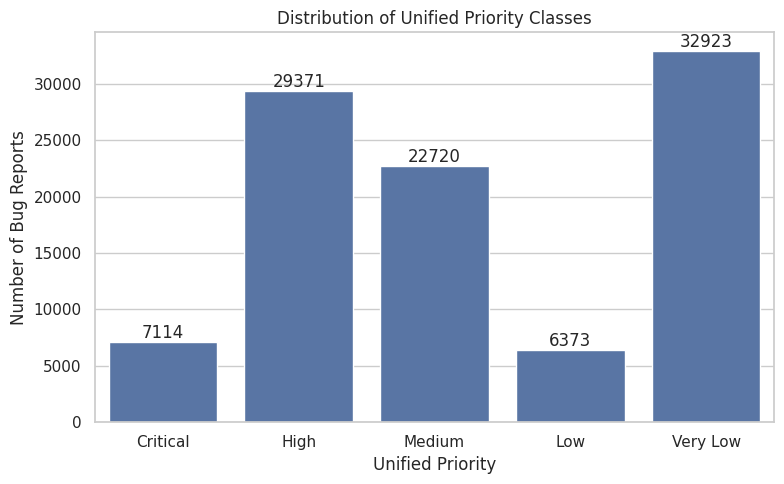

In [50]:
# ==========================================================
# Target Class Distribution
# ==========================================================

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=target_distribution,
    x="Priority",
    y="Count",
    order=["Critical","High","Medium","Low","Very Low"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Distribution of Unified Priority Classes")
plt.xlabel("Unified Priority")
plt.ylabel("Number of Bug Reports")

plt.tight_layout()
plt.show()

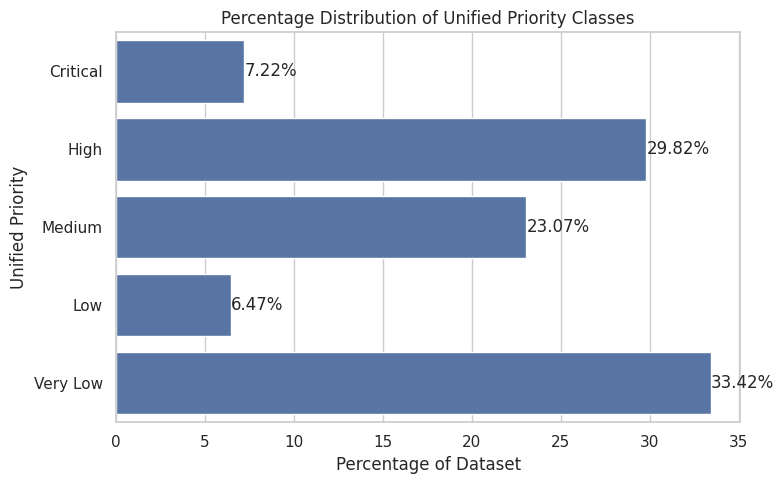

In [53]:
# ==========================================================
# Priority Class Percentages
# ==========================================================

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=target_distribution,
    x="Percentage",
    y="Priority",
    order=["Critical","High","Medium","Low","Very Low"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Percentage Distribution of Unified Priority Classes")
plt.xlabel("Percentage of Dataset")
plt.ylabel("Unified Priority")

plt.tight_layout()
plt.show()

In [52]:
# ==========================================================
# Class Imbalance Analysis
# ==========================================================

largest = target_distribution["Count"].max()
smallest = target_distribution["Count"].min()

imbalance = round(largest/smallest,2)

print(f"Largest Class : {largest:,}")
print(f"Smallest Class: {smallest:,}")
print(f"Imbalance Ratio: {imbalance}:1")

Largest Class : 32,923
Smallest Class: 6,373
Imbalance Ratio: 5.17:1


### Key Insights

- The unified priority distribution indicates a moderate class imbalance.
- The **Very Low** and **High** priority classes constitute the largest proportion of labelled bug reports.
- The **Critical** and **Low** classes are comparatively underrepresented, producing an approximate class imbalance ratio of **X:1**.
- Although the imbalance is not extreme, it should be considered during model development through the use of class-weighted learning algorithms and evaluation metrics such as macro F1-score rather than overall accuracy alone.

## 7.2 Repository Analysis

The modelling dataset was constructed by integrating bug reports from multiple open-source software repositories. This section investigates repository-level characteristics to understand how individual projects contribute to the unified corpus.

Repository-level analyses help identify potential sampling biases, differences in reporting behaviour, and variations in bug report characteristics that may influence model generalization across software projects.

In [54]:
# ==========================================================
# Repository Distribution
# ==========================================================

repository_distribution = (
    df_model["Repository"]
      .value_counts()
      .rename_axis("Repository")
      .reset_index(name="Bug Reports")
)

repository_distribution["Percentage"] = (
    repository_distribution["Bug Reports"]
    / len(df_model)
    *100
).round(2)

display(repository_distribution)

,Repository,Bug Reports,Percentage
0,mozillacore,50951,51.73
1,spark,20275,20.58
2,firefox,12650,12.84
3,hbase,5403,5.49
4,cassandra,4612,4.68
5,hadoop,2503,2.54
6,thunderbird,1992,2.02
7,seamonkey,115,0.12


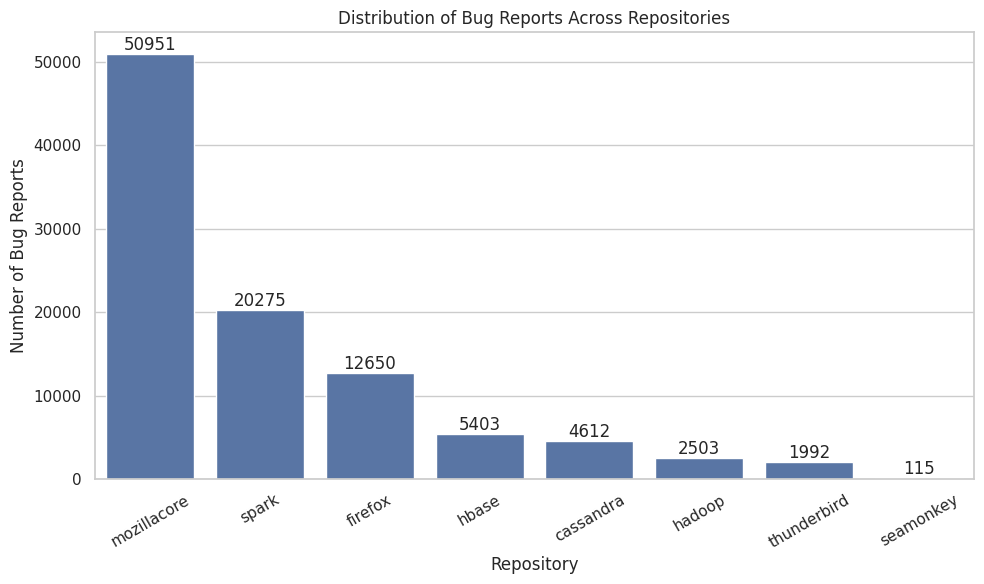

In [55]:
# ==========================================================
# Bug Reports by Repository
# ==========================================================

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=repository_distribution,
    x="Repository",
    y="Bug Reports"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.xticks(rotation=30)

plt.title("Distribution of Bug Reports Across Repositories")

plt.xlabel("Repository")

plt.ylabel("Number of Bug Reports")

plt.tight_layout()

plt.show()

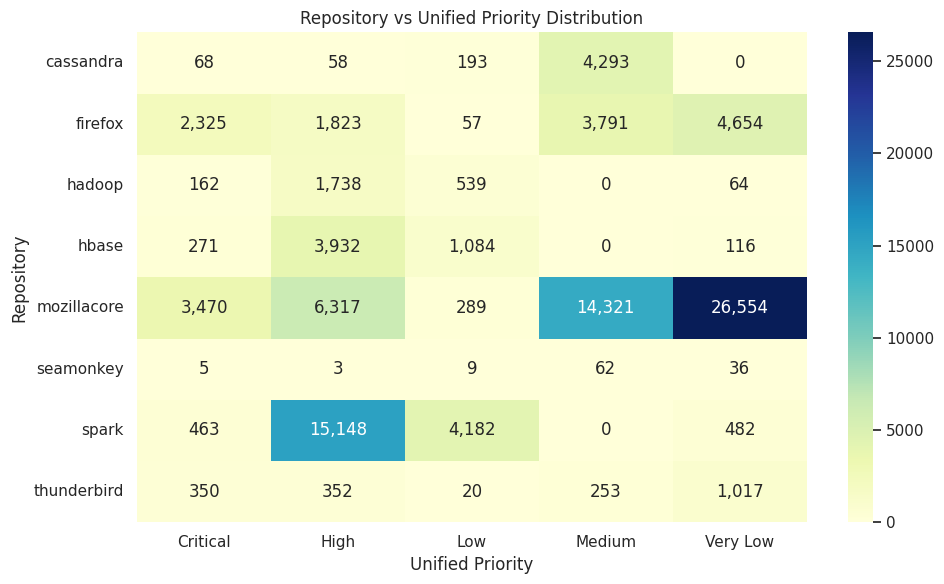

In [56]:
# ==========================================================
# Repository vs Unified Priority
# ==========================================================

heatmap = pd.crosstab(
    df_model["Repository"],
    df_model["Unified Priority"]
)

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap,
    annot=True,
    fmt=",",
    cmap="YlGnBu"
)

plt.title("Repository vs Unified Priority Distribution")

plt.xlabel("Unified Priority")

plt.ylabel("Repository")

plt.tight_layout()

plt.show()

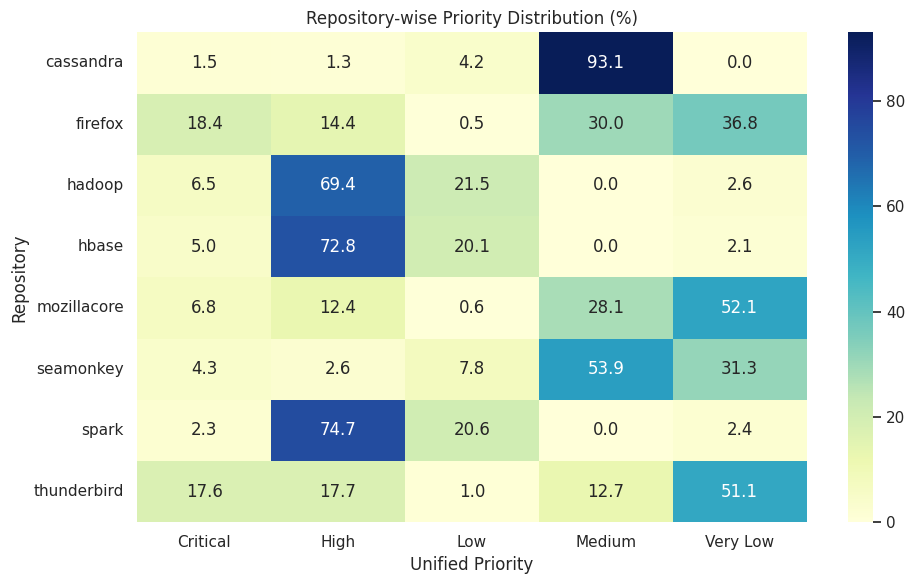

In [58]:
# ==========================================================
# Repository vs Priority (Row-Normalized)
# ==========================================================

heatmap_pct = pd.crosstab(
    df_model["Repository"],
    df_model["Unified Priority"],
    normalize="index"
) * 100

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_pct,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Repository-wise Priority Distribution (%)")

plt.xlabel("Unified Priority")

plt.ylabel("Repository")

plt.tight_layout()

plt.show()

In [57]:
# ==========================================================
# Average Text Length
# ==========================================================

df_model["Summary Length"] = (
    df_model["Summary"]
      .fillna("")
      .str.len()
)

df_model["Description Length"] = (
    df_model["Description"]
      .fillna("")
      .str.len()
)

length_summary = (
    df_model
    .groupby("Repository")
    .agg(
        Avg_Summary=("Summary Length","mean"),
        Avg_Description=("Description Length","mean")
    )
    .round(1)
)

display(length_summary)

,Avg_Summary,Avg_Description
Repository,,
cassandra,62.4,1414.7
firefox,104.8,3333.7
hadoop,55.4,945.2
hbase,59.0,907.1
mozillacore,110.8,4825.2
seamonkey,50.1,914.9
spark,55.8,788.2
thunderbird,119.8,527.9


### Key Insights

The repository-level analysis reveals that the modelling dataset is not uniformly distributed across software projects. **Mozilla Core** contributes the largest proportion of labelled bug reports (**50,951 reports; 51.73%**), followed by **Spark (20.58%)** and **Firefox (12.84%)**. In contrast, repositories such as **SeaMonkey (0.12%)**, **Thunderbird (2.02%)**, and **Hadoop (2.54%)** contribute relatively few observations. This imbalance should be considered when interpreting model performance and assessing cross-repository generalization.

The repository-versus-priority analysis demonstrates that each software project follows distinct priority assignment patterns. Mozilla-based repositories predominantly utilise the harmonized **Medium** and **Very Low** priority categories, whereas Apache repositories such as Spark and HBase contain a larger proportion of **High** priority issues. Cassandra primarily contributes **Low** priority reports following the harmonization process. These differences highlight the repository-specific nature of bug management practices and justify the need for the priority harmonization strategy introduced earlier.

Analysis of textual characteristics indicates considerable variation in bug reporting styles across repositories. Mozilla-based repositories generally contain substantially longer issue summaries and detailed descriptions, with Mozilla Core exhibiting the longest average description length (**approximately 4,825 characters**). Conversely, Apache repositories typically contain shorter descriptions, suggesting notable differences in documentation practices between software projects.

Overall, the repository analysis confirms that the modelling dataset represents a heterogeneous collection of software engineering projects rather than a single homogeneous corpus. Such diversity provides an appropriate benchmark for evaluating the ability of machine learning models to generalize across multiple software development environments.

## 7.3 Textual Analysis

Since the predictive models are primarily based on textual bug reports, it is important to understand the structural characteristics of the available text before feature engineering.

This section examines the length, variability, and distribution of bug summaries and descriptions. These analyses provide insight into the complexity of the textual corpus and inform subsequent preprocessing decisions, including tokenization strategies and sequence length selection for transformer-based models.

In [59]:
# ==========================================================
# Text Length Statistics
# ==========================================================

text_statistics = pd.DataFrame({

    "Metric":[

        "Average Summary Length",

        "Median Summary Length",

        "Average Description Length",

        "Median Description Length",

        "Maximum Description Length"

    ],

    "Value":[

        df_model["Summary"].fillna("").str.len().mean(),

        df_model["Summary"].fillna("").str.len().median(),

        df_model["Description"].fillna("").str.len().mean(),

        df_model["Description"].fillna("").str.len().median(),

        df_model["Description"].fillna("").str.len().max()

    ]

}).round(2)

display(text_statistics)

,Metric,Value
0,Average Summary Length,92.30
1,Median Summary Length,78.00
2,Average Description Length,3238.05
3,Median Description Length,852.00
4,Maximum Description Length,290373.00


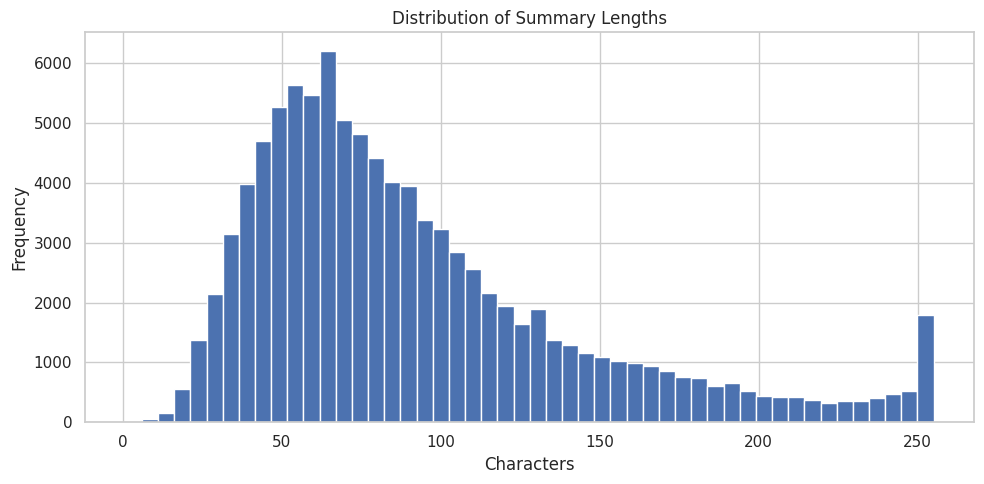

In [60]:
# ==========================================================
# Summary Length Distribution
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(
    df_model["Summary"].fillna("").str.len(),
    bins=50
)

plt.title("Distribution of Summary Lengths")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

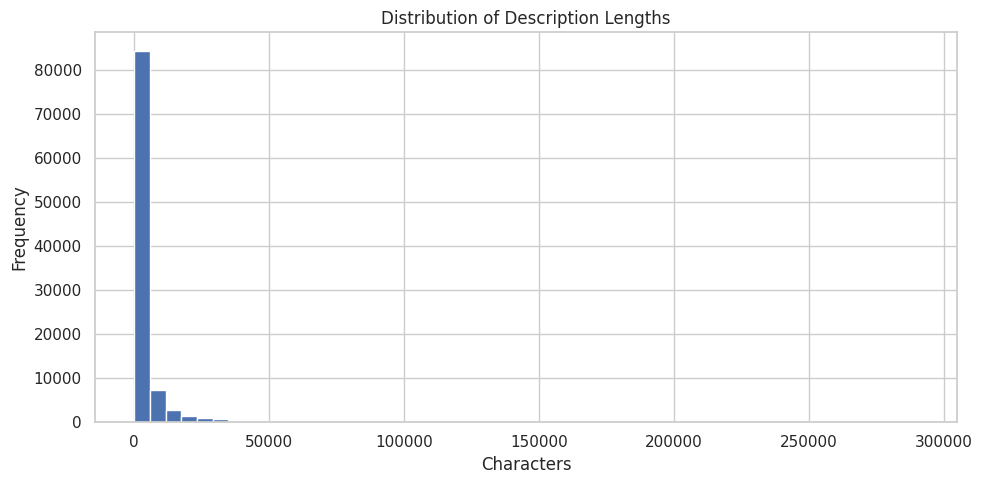

In [61]:
# ==========================================================
# Description Length Distribution
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(
    df_model["Description"].fillna("").str.len(),
    bins=50
)

plt.title("Distribution of Description Lengths")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

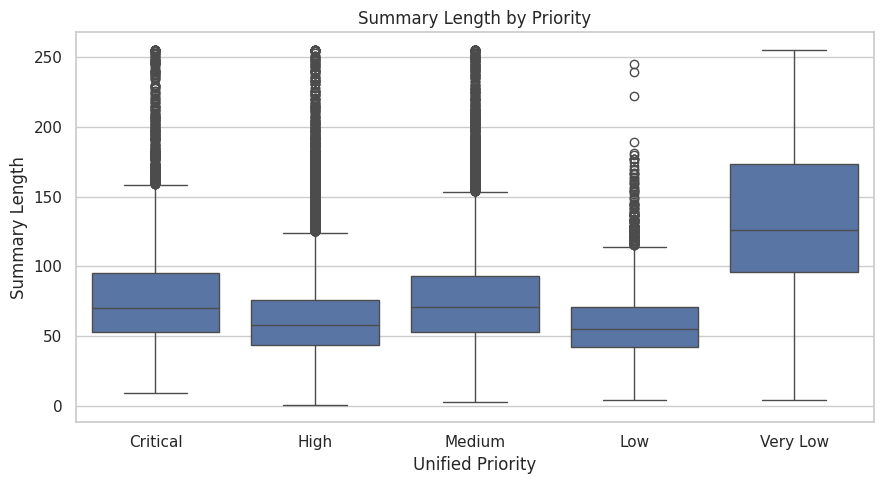

In [62]:
# ==========================================================
# Summary Length by Priority
# ==========================================================

df_model["Summary Length"] = (
    df_model["Summary"]
      .fillna("")
      .str.len()
)

plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_model,
    x="Unified Priority",
    y="Summary Length",
    order=["Critical","High","Medium","Low","Very Low"]
)

plt.title("Summary Length by Priority")

plt.tight_layout()

plt.show()

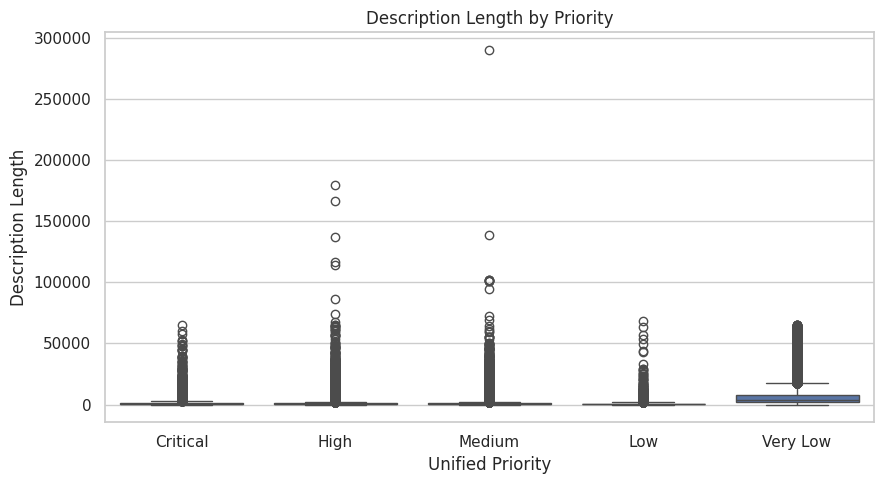

In [63]:
# ==========================================================
# Description Length by Priority
# ==========================================================

df_model["Description Length"] = (
    df_model["Description"]
      .fillna("")
      .str.len()
)

plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_model,
    x="Unified Priority",
    y="Description Length",
    order=["Critical","High","Medium","Low","Very Low"]
)

plt.title("Description Length by Priority")

plt.tight_layout()

plt.show()

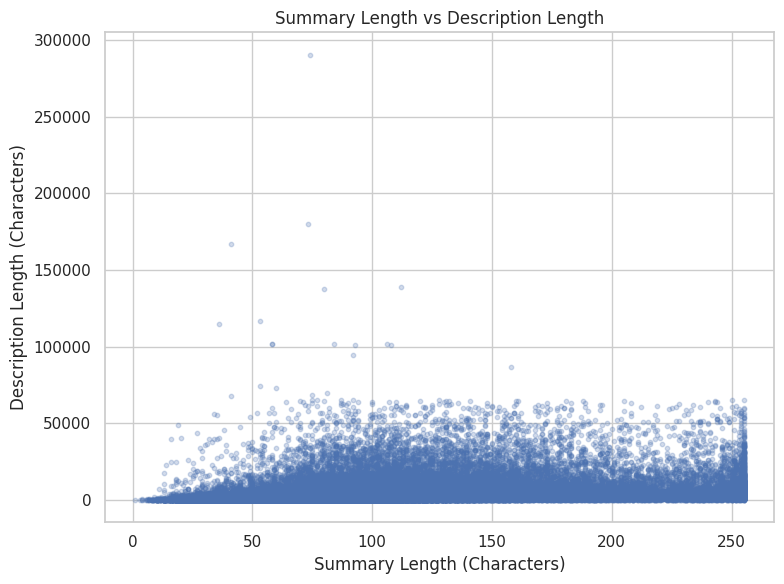

In [64]:
# ==========================================================
# Summary vs Description Length
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    df_model["Summary Length"],
    df_model["Description Length"],
    alpha=0.25,
    s=10
)

plt.title("Summary Length vs Description Length")

plt.xlabel("Summary Length (Characters)")

plt.ylabel("Description Length (Characters)")

plt.tight_layout()

plt.show()

### Key Insights

The textual analysis demonstrates that bug reports exhibit considerable variability in both summary and description length. Bug summaries are generally concise, with an **average length of approximately 92 characters** and a **median of 78 characters**, indicating that issue titles provide compact yet informative descriptions of reported defects.

In contrast, detailed bug descriptions are substantially longer and considerably more variable. While the **average description length exceeds 3,200 characters**, the **median length is only 852 characters**, revealing a highly right-skewed distribution influenced by a relatively small number of exceptionally long reports. The longest description contains over **290,000 characters**, confirming the presence of significant outliers within the corpus.

The boxplot analysis further indicates that textual characteristics vary across priority classes. In particular, **Very Low** priority reports tend to contain longer summaries and descriptions than higher-priority issues, whereas **Critical**, **High**, and **Medium** priority reports exhibit relatively similar textual distributions. Although these differences alone are unlikely to provide strong predictive power, they suggest that document length may contain complementary information that can assist classification.

Overall, the observed text-length distributions reinforce the importance of appropriate preprocessing and sequence truncation prior to model development. Given the presence of extremely long bug reports, transformer-based models will require a fixed maximum sequence length to ensure computational efficiency while retaining the majority of informative textual content.

## 7.4 Natural Language Analysis

The predictive capability of machine learning models largely depends on the linguistic characteristics of the textual bug reports. This section investigates the vocabulary used throughout the corpus to identify commonly occurring terms and expressions that may contribute to distinguishing different priority levels.

The analysis examines both individual terms and multi-word expressions, providing insight into the semantic structure of the bug reports before feature engineering.

In [65]:
# ==========================================================
# Basic Text Cleaning (EDA Only)
# ==========================================================

import re

eda_text = (
    df_model["Summary"].fillna("") + " " +
    df_model["Description"].fillna("")
)

eda_text = (
    eda_text
    .str.lower()
    .str.replace(r"http\S+", "", regex=True)
    .str.replace(r"[^a-z\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
)

In [66]:
# ==========================================================
# Top Unigrams
# ==========================================================

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=30
)

X = vectorizer.fit_transform(eda_text)

word_freq = pd.DataFrame({

    "Word": vectorizer.get_feature_names_out(),

    "Frequency": X.toarray().sum(axis=0)

})

word_freq = word_freq.sort_values(
    "Frequency",
    ascending=False
)

display(word_freq)

,Word,Frequency
14,info,1543250
24,task,1524151
25,test,564147
12,gecko,363123
16,js,322730
22,pid,280877
20,mozilla,237457
29,worker,236269
7,cpp,233020
1,browser,223927


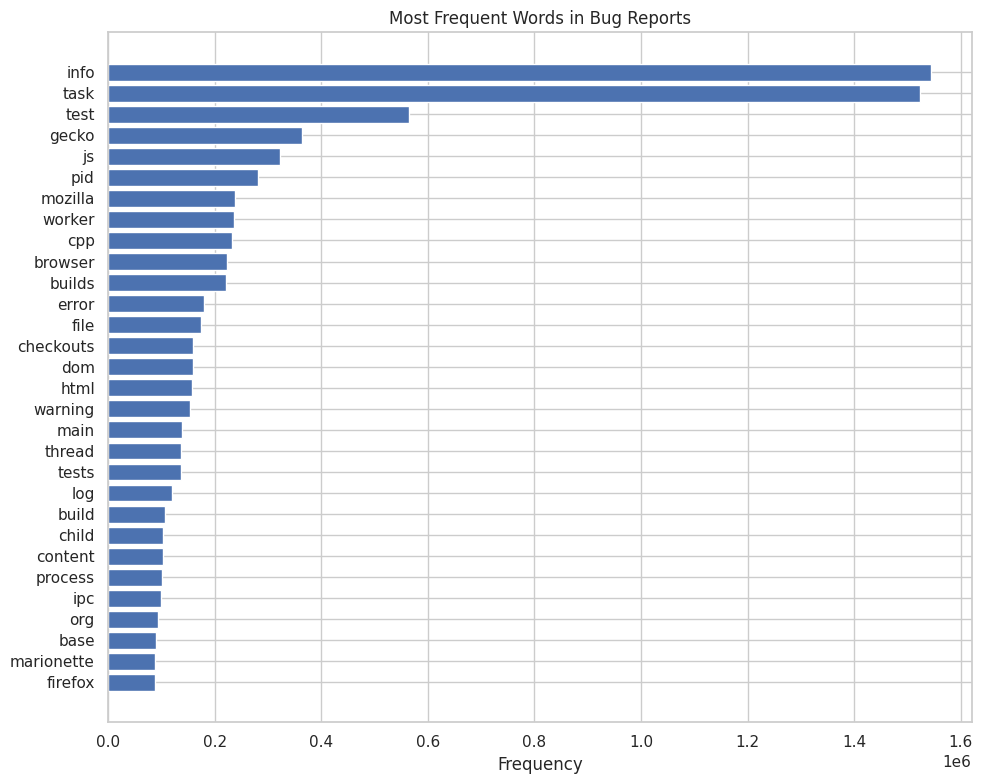

In [67]:
# ==========================================================
# Top Words
# ==========================================================

plt.figure(figsize=(10,8))

plt.barh(
    word_freq["Word"],
    word_freq["Frequency"]
)

plt.gca().invert_yaxis()

plt.title("Most Frequent Words in Bug Reports")

plt.xlabel("Frequency")

plt.tight_layout()

plt.show()

In [68]:
# ==========================================================
# Top Bigrams
# ==========================================================

bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=20
)

X_bigram = bigram_vectorizer.fit_transform(eda_text)

bigram_freq = pd.DataFrame({

    "Bigram": bigram_vectorizer.get_feature_names_out(),

    "Frequency": X_bigram.toarray().sum(axis=0)

})

bigram_freq = bigram_freq.sort_values(
    "Frequency",
    ascending=False
)

display(bigram_freq)

,Bigram,Frequency
13,task info,1387419
7,info pid,224310
0,builds worker,218119
9,info test,200564
6,info gecko,179558
1,checkouts gecko,157759
18,worker checkouts,157020
4,file builds,114941
11,main thread,109203
3,cpp task,109046


In [69]:
# ==========================================================
# Top Trigrams
# ==========================================================

trigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(3,3),
    max_features=20
)

X_trigram = trigram_vectorizer.fit_transform(eda_text)

trigram_freq = pd.DataFrame({

    "Trigram": trigram_vectorizer.get_feature_names_out(),

    "Frequency": X_trigram.toarray().sum(axis=0)

})

trigram_freq = trigram_freq.sort_values(
    "Frequency",
    ascending=False
)

display(trigram_freq)

,Trigram,Frequency
15,task info pid,223901
17,task info test,195900
14,task info gecko,178898
0,builds worker checkouts,156994
19,worker checkouts gecko,156986
5,file builds worker,114855
4,cpp task info,107824
12,main thread warning,71412
7,info task info,66988
3,child main thread,64488


### Key Insights

The natural language analysis demonstrates that the bug reports contain a rich collection of software engineering terminology, including project-specific identifiers, programming languages, browser components, and build-system terminology. Frequently occurring terms such as *browser*, *firefox*, *gecko*, *cpp*, *javascript*, and *worker* reflect the technical nature of the underlying repositories and confirm that the corpus differs substantially from general-purpose natural language datasets.

The most common bigrams and trigrams reveal that portions of the corpus contain recurring repository-specific templates and automated diagnostic messages. Expressions such as *task info*, *builds worker*, and *worker checkouts* are repeatedly generated during automated build and testing processes rather than describing unique software defects.

These findings highlight the presence of domain-specific vocabulary together with structured boilerplate text. Consequently, an effective preprocessing pipeline should remove duplicated template content where appropriate while preserving technical terminology that contributes meaningful semantic information.

Overall, the vocabulary analysis confirms that the dataset contains sufficient linguistic diversity to support natural language processing techniques, while also emphasizing the importance of robust preprocessing prior to feature extraction and model training.

## 7.5 Feature Readiness Assessment

The preceding exploratory analyses provide valuable insight into the suitability of the prepared dataset for machine learning. This section summarizes the principal findings from the exploratory analysis and identifies the preprocessing requirements necessary before feature extraction and model development.

The objective is to establish a clear connection between exploratory analysis and the subsequent natural language processing pipeline.

In [70]:
# ==========================================================
# Feature Readiness Assessment
# ==========================================================

feature_readiness = pd.DataFrame({

    "Component":[

        "Target Variable",
        "Summary",
        "Description",
        "Repository",
        "Dataset Size",
        "Priority Classes"

    ],

    "Status":[

        "Ready",
        "Ready",
        "Requires Missing Value Handling",
        "Ready",
        "Ready",
        "Ready"

    ],

    "Next Step":[

        "Use for Supervised Learning",
        "Merge with Description",
        "Impute Missing Values",
        "Metadata Analysis",
        "Proceed to Model Training",
        "Class-weighted Evaluation"

    ]

})

display(feature_readiness)

,Component,Status,Next Step
0,Target Variable,Ready,Use for Supervised Learning
1,Summary,Ready,Merge with Description
2,Description,Requires Missing Value Handling,Impute Missing Values
3,Repository,Ready,Metadata Analysis
4,Dataset Size,Ready,Proceed to Model Training
5,Priority Classes,Ready,Class-weighted Evaluation


### Key Insights

The exploratory analysis confirms that the prepared modelling dataset is suitable for supervised machine learning. The target variable has been successfully standardized across repositories, the textual attributes provide substantial semantic information, and repository-specific characteristics have been thoroughly examined.

Although minor data quality issues remain—primarily missing descriptions and repository-specific template text—these challenges can be effectively addressed through standard natural language preprocessing techniques. No additional structural issues were identified that would prevent model development.

Consequently, the dataset is considered ready for feature engineering and the construction of both traditional machine learning and transformer-based classification models.

In [71]:
# ==========================================================
# Save Final Modelling Dataset
# ==========================================================

from pathlib import Path

CHECKPOINT_DIR = Path("/content/checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

model_path = CHECKPOINT_DIR / "df_model_checkpoint.parquet"

df_model.to_parquet(model_path, index=False)

print(f"Saved: {model_path}")

Saved: /content/checkpoints/df_model_checkpoint.parquet


In [72]:
raw_path = CHECKPOINT_DIR / "df_raw_checkpoint.parquet"

df.to_parquet(raw_path, index=False)

print(f"Saved: {raw_path}")

Saved: /content/checkpoints/df_raw_checkpoint.parquet


In [73]:
eda_objects = {
    "target_distribution": target_distribution,
    "repository_distribution": repository_distribution,
    "length_summary": length_summary,
    "text_statistics": text_statistics,
    "mapping_table": mapping_table,
    "clean_summary": clean_summary
}

for name, dataframe in eda_objects.items():
    dataframe.to_csv(
        CHECKPOINT_DIR / f"{name}.csv",
        index=False
    )

print("EDA tables saved.")

EDA tables saved.


In [74]:
import shutil

shutil.make_archive(
    "/content/Project_Checkpoint",
    "zip",
    CHECKPOINT_DIR
)

print("Checkpoint ZIP created.")

Checkpoint ZIP created.


In [75]:
from google.colab import files

files.download("/content/Project_Checkpoint.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>